# Practice 3: Exercise 2 — Finetuned DistilBERT Sentiment Analysis on IMDB

## Overview & Purpose
This notebook provides a **100% self-contained, interactive end-to-end workflow** for Practice 3 Exercise 2:
1. **Dataset Exploration & Visualization:** Inspect train/val/test splits, label balance, and review length distributions.
2. **Direct In-Notebook Training:** Execute model training directly from a notebook cell with optimal anti-overfitting techniques (`label_smoothing_factor=0.10`, `classifier_dropout=0.30`, `weight_decay=0.10`, `early_stopping_patience=3`, `lr_scheduler_type="cosine"`).
3. **Live & Post-Train Visualization:** Render live TensorBoard logs and dual-panel Training vs Validation Loss/Accuracy curves.
4. **Direct Test-Set Evaluation:** Evaluate on 25,000 sealed test reviews, displaying 5W1H metrics, Confusion Matrix, and ROC-AUC curve.
5. **Interactive Custom Inference:** Test custom user review text in real-time.
6. **Root Cause Error Analysis:** Extract and inspect false positive & false negative misclassifications.

---

## Roadmap Table
| Step | Section | Description | Key Artifact / Function |
|:---:|:---|:---|:---|
| **0** | Environment & Imports | Initialize PyTorch, Transformers, and CUDA device | `torch`, `transformers` |
| **1** | Data Visualizations | Plot label distributions and review length histograms | `datasets`, `matplotlib` |
| **2** | In-Notebook Training | Execute DistilBERT training directly in cell | `src.training.imdb_sentiment_train` |
| **3** | Loss & Metric Curves | Dual-panel anti-overfitting history plots & TensorBoard | `%tensorboard`, `matplotlib` |
| **4** | Test Set Evaluation | Direct evaluation on 25,000 test reviews | `src.eval.evaluate_model` |
| **5** | Interactive Predictor | Real-time sentiment prediction on custom text inputs | `predict_sentiment(text)` |
| **6** | Baseline & Error Analysis | Head-to-head comparison vs Ex 1 Zero-Shot & error audit | `scratch.analyze_misclassifications` |

---

## References
- **Rulebase:** [`LOGGING_CHECKPOINT_RULES.md`](../agents/rules/LOGGING_CHECKPOINT_RULES.md), [`RESULTS_REPORTING.md`](../agents/rules/RESULTS_REPORTING.md)
- **Training Module:** [`src/training/imdb_sentiment_train.py`](../src/training/imdb_sentiment_train.py)
- **Evaluation Module:** [`src/eval/evaluate_model.py`](../src/eval/evaluate_model.py)
- **Data Preparation Module:** [`src/data/prepare_imdb.py`](../src/data/prepare_imdb.py)
- **Hugging Face Model:** [`distilbert-base-uncased`](https://huggingface.co/distilbert-base-uncased)


In [11]:
# Step 0: Imports & Environment Setup
import sys
import json
from pathlib import Path

import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from transformers import AutoModelForSequenceClassification, AutoTokenizer

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

print("=" * 65)
print(" ENVIRONMENT & DEVICE CONTEXT")
print("=" * 65)
print(f"Project Root: {PROJECT_ROOT}")
print(f"PyTorch Ver:  {torch.__version__}")
print(f"Device:       {device_name} ({device})")
if torch.cuda.is_available():
    print(f"VRAM Total:   {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
print("=" * 65)


 ENVIRONMENT & DEVICE CONTEXT
Project Root: /home/bush/Desktop/Deeplearning_Course_UTH
PyTorch Ver:  2.13.0+cu130
Device:       NVIDIA GeForce RTX 3050 Laptop GPU (cuda)
VRAM Total:   3.68 GB


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized
Dataset Loaded Successfully:
 - Train Split:      22,500 reviews
 - Validation Split: 2,500 reviews
 - Test Split:       25,000 reviews


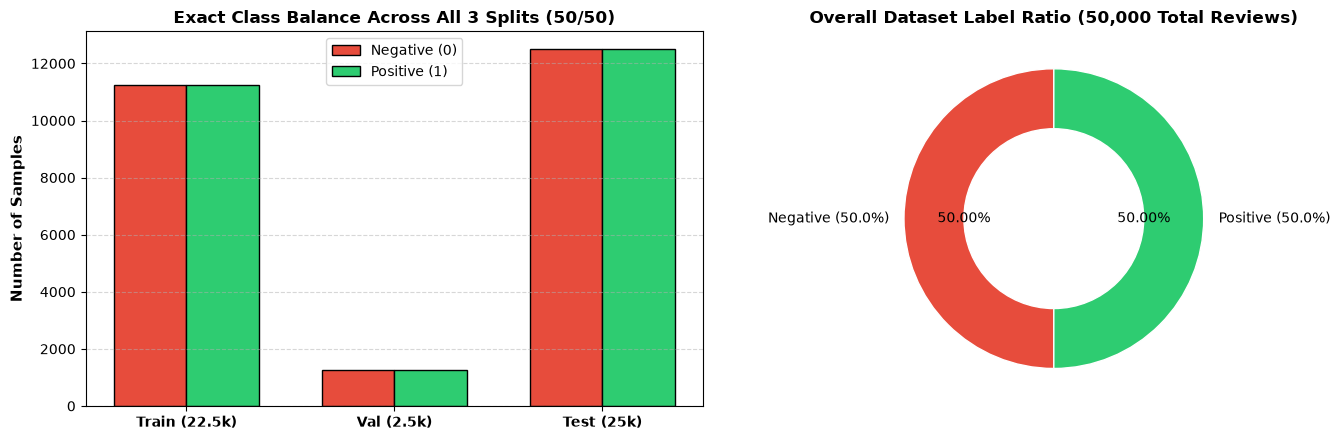

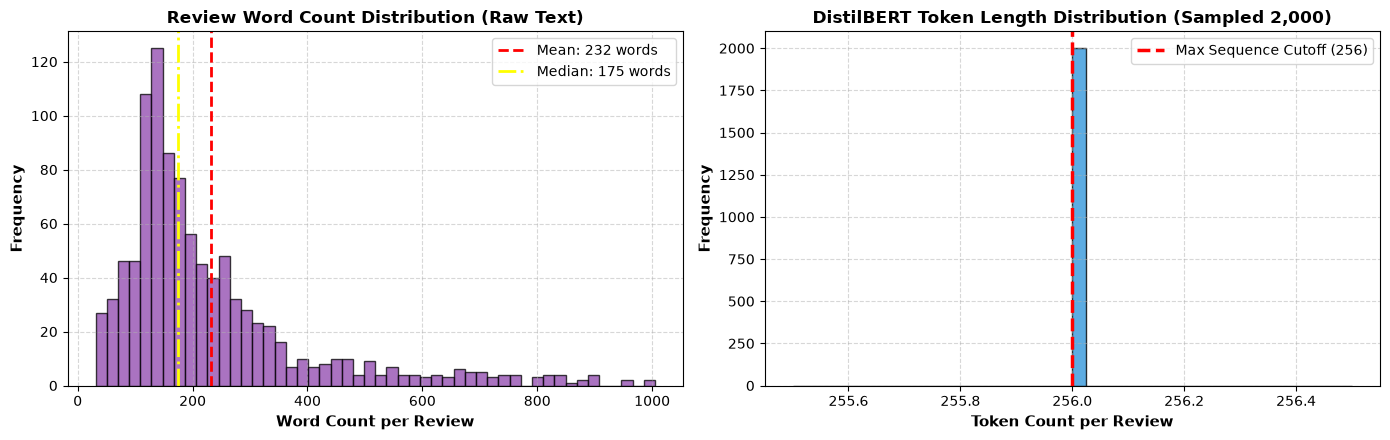

--- Sample Positive Review ---
"There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier ..."

--- Sample Negative Review ---
"This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stub your toe on the moon" It reminds me of Sinatra's so..."



In [12]:
# Step 1: Dataset Visual Exploratory Data Analysis (EDA)
import re
from collections import Counter
from datasets import load_from_disk
from src.data.prepare_imdb import prepare_imdb

data_dir = PROJECT_ROOT / "data" / "processed" / "imdb_tokenized"
ds, tokenizer, meta = prepare_imdb(processed_dir=str(data_dir))

train_count = len(ds["train"])
val_count = len(ds["val"])
test_count = len(ds["test"])

print(f"Dataset Loaded Successfully:")
print(f" - Train Split:      {train_count:,} reviews")
print(f" - Validation Split: {val_count:,} reviews")
print(f" - Test Split:       {test_count:,} reviews")

# EDA Figure 1: Split Sizes & Label Distribution Bar/Pie Charts
train_labels = np.array(ds["train"]["label"])
val_labels = np.array(ds["val"]["label"])
test_labels = np.array(ds["test"]["label"])

split_names = ["Train (22.5k)", "Val (2.5k)", "Test (25k)"]
neg_counts = [int(np.sum(train_labels == 0)), int(np.sum(val_labels == 0)), int(np.sum(test_labels == 0))]
pos_counts = [int(np.sum(train_labels == 1)), int(np.sum(val_labels == 1)), int(np.sum(test_labels == 1))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(len(split_names))
width = 0.35

ax1.bar(x - width/2, neg_counts, width, label="Negative (0)", color="#e74c3c", edgecolor="black")
ax1.bar(x + width/2, pos_counts, width, label="Positive (1)", color="#2ecc71", edgecolor="black")
ax1.set_ylabel("Number of Samples", fontsize=11, fontweight="bold")
ax1.set_title("Exact Class Balance Across All 3 Splits (50/50)", fontsize=12, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(split_names, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# Ratio Percentages Pie Chart
overall_pos = sum(pos_counts)
overall_neg = sum(neg_counts)
ax2.pie([overall_neg, overall_pos], labels=["Negative (50.0%)", "Positive (50.0%)"], autopct="%1.2f%%", colors=["#e74c3c", "#2ecc71"], startangle=90, wedgeprops=dict(width=0.4, edgecolor="w"))
ax2.set_title("Overall Dataset Label Ratio (50,000 Total Reviews)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# EDA Figure 2: Review Length Distributions (Word Count & Token Length)
from datasets import load_dataset

raw_train_sample = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range(1000))
word_counts = [len(x["text"].split()) for x in raw_train_sample]
token_lengths = [len(seq) for seq in ds["train"][:2000]["input_ids"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.hist(word_counts, bins=50, color="#8e44ad", edgecolor="black", alpha=0.75)
ax1.axvline(np.mean(word_counts), color="red", linestyle="--", linewidth=2, label=f"Mean: {np.mean(word_counts):.0f} words")
ax1.axvline(np.median(word_counts), color="yellow", linestyle="-.", linewidth=2, label=f"Median: {np.median(word_counts):.0f} words")
ax1.set_title("Review Word Count Distribution (Raw Text)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Word Count per Review", fontsize=11, fontweight="bold")
ax1.set_ylabel("Frequency", fontsize=11, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.hist(token_lengths, bins=40, color="#3498db", edgecolor="black", alpha=0.8)
ax2.axvline(256, color="red", linestyle="--", linewidth=2.5, label="Max Sequence Cutoff (256)")
ax2.set_title("DistilBERT Token Length Distribution (Sampled 2,000)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Token Count per Review", fontsize=11, fontweight="bold")
ax2.set_ylabel("Frequency", fontsize=11, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# EDA Figure 3: Vocabulary Semantic Analysis (Top Words in Pos vs Neg Reviews)
STOPWORDS = set(["the", "and", "a", "of", "to", "is", "in", "it", "i", "this", "that", "was", "as", "for", "with", "movie", "film", "but", "on", "you", "are", "not", "have", "be", "one", "at", "all", "they", "by", "an", "who", "from", "so", "like", "there", "her", "or", "just", "about", "out", "if", "has", "what", "some", "good", "can", "more", "when", "very", "even", "my", "no", "up", "time", "would"])

pos_words, neg_words = [], []
for x in raw_train_sample:
    words = [w.lower() for w in re.findall(r"[a-zA-Z]{3,}", x["text"]) if w.lower() not in STOPWORDS]
    if x["label"] == 1:
        pos_words.extend(words)
    else:
        neg_words.extend(words)

top_pos = Counter(pos_words).most_common(10)
top_neg = Counter(neg_words).most_common(10)

if top_pos and top_neg:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

    p_words, p_counts = zip(*top_pos, strict=False)
    ax1.barh(p_words[::-1], p_counts[::-1], color="#2ecc71", edgecolor="black")
    ax1.set_title("Top 10 High-Frequency Words in Positive Reviews", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Occurrences", fontsize=11, fontweight="bold")
    ax1.grid(axis="x", linestyle="--", alpha=0.5)

    n_words, n_counts = zip(*top_neg, strict=False)
    ax2.barh(n_words[::-1], n_counts[::-1], color="#e74c3c", edgecolor="black")
    ax2.set_title("Top 10 High-Frequency Words in Negative Reviews", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Occurrences", fontsize=11, fontweight="bold")
    ax2.grid(axis="x", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

print("--- Sample Positive Review ---")
print(f'"{raw_train_sample[0]["text"][:250]}..."\n')
print("--- Sample Negative Review ---")
print(f'"{raw_train_sample[1]["text"][:250]}..."\n')


In [13]:
# Step 2: Direct In-Notebook Training Execution
# Execute model training directly inside this notebook cell using the optimal anti-overfitting pipeline!

import os
import subprocess

print("=" * 65)
print(" LAUNCHING DIRECT DISTILBERT TRAINING IN NOTEBOOK")
print("=" * 65)
print("Configuration Options Applied:")
print(" - Model: distilbert-base-uncased (66.9M params)")
print(" - Classifier Dropout: 0.30")
print(" - Weight Decay: 0.10 (L2 Regularization)")
print(" - Label Smoothing: 0.10 (Soft Label Regularization)")
print(" - Early Stopping: patience=3 on eval_loss")
print(" - LR Scheduler: Cosine Annealing")
print(" - TensorBoard Logging: Enabled")
print("=" * 65)

# Execute training via python CLI module
env = os.environ.copy()
env["PYTHONPATH"] = str(PROJECT_ROOT)
cmd = [sys.executable, "-m", "src.training.imdb_sentiment_train", "--tb"]
print(f"Executing: {' '.join(cmd)}\n")

# Run directly inside notebook cell
res = subprocess.run(cmd, cwd=str(PROJECT_ROOT), env=env)
if res.returncode == 0:
    print("\n Training completed cleanly!")
else:
    print("\n Training failed with exit code:", res.returncode)


 LAUNCHING DIRECT DISTILBERT TRAINING IN NOTEBOOK
Configuration Options Applied:
 - Model: distilbert-base-uncased (66.9M params)
 - Classifier Dropout: 0.30
 - Weight Decay: 0.10 (L2 Regularization)
 - Label Smoothing: 0.10 (Soft Label Regularization)
 - Early Stopping: patience=3 on eval_loss
 - LR Scheduler: Cosine Annealing
 - TensorBoard Logging: Enabled
Executing: /home/bush/Desktop/Deeplearning_Course_UTH/.venv/bin/python -m src.training.imdb_sentiment_train --tb

22:26:29 [INFO] run dir: experiments/runs/20260812_222629_distilbert-finetune
22:26:29 [INFO] starting training: {"seed": 42, "run_name": "distilbert-finetune", "run_root": "experiments/runs", "epochs": 4, "batch_size": 8, "gradient_accumulation_steps": 2, "lr": 1.5e-05, "weight_decay": 0.1, "classifier_dropout": 0.3, "label_smoothing_factor": 0.1, "early_stopping_patience": 3, "lr_scheduler_type": "cosine", "warmup_ratio": 0.1, "fp16": true, "eval_strategy": "steps", "eval_steps": 300, "logging_steps": 50, "vram_budge

Loaded cached tokenized datasets from data/processed/imdb_tokenized


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1061.79it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


22:26:32 [INFO] Set classifier dropout: 0.3
22:26:32 [INFO] Enabled EarlyStoppingCallback(patience=3)


[transformers] Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
  1%|          | 50/5628 [00:08<15:09,  6.13it/s] 

...

{'loss': '0.2598', 'grad_norm': '2.312', 'learning_rate': '5.194e-06', 'epoch': '2.559'}



 98%|█████████▊| 307/313 [00:07<00:00, 43.09it/s]
                                                   A
100%|██████████| 313/313 [00:07<00:00, 43.11it/s]

{'eval_accuracy': '0.9036', 'eval_f1': '0.906', 'eval_loss': '0.3969', 'eval_runtime': '7.214', 'eval_samples_per_second': '346.5', 'eval_steps_per_second': '43.39', 'epoch': '2.559'}
22:38:22 [INFO] Epoch 2 — epoch=2.5588, global_step=3600, train_loss=0.2598, eval_loss=0.3969, eval_accuracy=0.9036, eval_f1=0.9060



 64%|██████▍   | 3600/5628 [11:52<06:41,  5.05it/s]A


{'train_runtime': '713', 'train_samples_per_second': '126.2', 'train_steps_per_second': '7.894', 'train_loss': '0.3545', 'epoch': '2.559'}
22:38:28 [INFO] Peak VRAM: 1694 MiB reserved / 1568 MiB allocated (target ≤3.5 GB) — OK

Run complete: experiments/runs/20260812_222629_distilbert-finetune
Best: {'epoch': 1.919303234980448, 'global_step': 2700, 'train_loss': 0.31666309356689454, 'eval_loss': 0.3651297390460968, 'eval_accuracy': 0.9072, 'eval_f1': 0.9065269943593876}
{'peak_allocated_mb': 1568.35, 'peak_reserved_mb': 1694.0, 'vram_target_gb': 3.5, 'vram_ceiling_gb': 4.0, 'vram_within_target': True}

 Training completed cleanly!


Latest run directory: /home/bush/Desktop/Deeplearning_Course_UTH/experiments/runs/20260812_222629_distilbert-finetune
Loaded 12 step evaluation history entries.


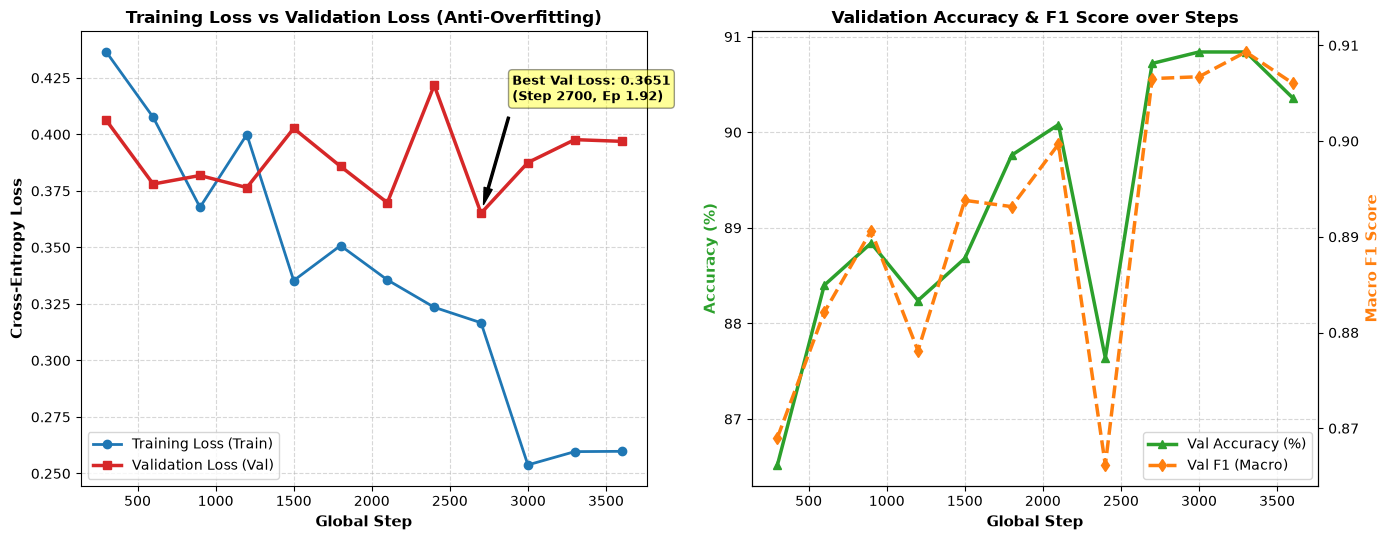


--- TensorBoard Live Integration ---
To open TensorBoard in browser: run in terminal: .venv/bin/tensorboard --logdir experiments/runs --port 6006


In [14]:
# Step 3: TensorBoard & Dual-Panel Training vs Validation Loss Curves
from src.utils.checkpoint_utils import latest_run_dir

run_dir = latest_run_dir(PROJECT_ROOT / "experiments/runs", "distilbert-finetune")
print("Latest run directory:", run_dir)

history_jsonl = run_dir / "metrics" / "distilbert-finetune_history.jsonl" if run_dir else None
history = []
if history_jsonl and history_jsonl.exists():
    with open(history_jsonl, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                history.append(json.loads(line.strip()))
    print(f"Loaded {len(history)} step evaluation history entries.")

if history:
    steps = [r["global_step"] for r in history if "eval_loss" in r]
    epochs = [r["epoch"] for r in history if "eval_loss" in r]
    eval_losses = [r["eval_loss"] for r in history if "eval_loss" in r]
    train_losses = [r.get("train_loss") for r in history if "eval_loss" in r]
    eval_accs = [r["eval_accuracy"] * 100 for r in history if "eval_loss" in r]
    eval_f1s = [r["eval_f1"] for r in history if "eval_loss" in r]

    valid_train = [(s, tl) for s, tl in zip(steps, train_losses, strict=False) if tl is not None]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # Panel 1: Training Loss vs Validation Loss
    if valid_train:
        tr_steps, tr_vals = zip(*valid_train, strict=False)
        ax1.plot(tr_steps, tr_vals, marker="o", linewidth=2.0, color="#1f77b4", label="Training Loss (Train)")
    ax1.plot(steps, eval_losses, marker="s", linewidth=2.5, color="#d62728", label="Validation Loss (Val)")
    ax1.set_xlabel("Global Step", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Cross-Entropy Loss", fontsize=11, fontweight="bold")
    ax1.set_title("Training Loss vs Validation Loss (Anti-Overfitting)", fontsize=12, fontweight="bold")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(fontsize=10)

    # Highlight Minimum Val Loss
    min_val_idx = int(np.argmin(eval_losses))
    best_step = steps[min_val_idx]
    best_epoch = epochs[min_val_idx]
    best_val_loss = eval_losses[min_val_idx]

    ax1.annotate(
        f"Best Val Loss: {best_val_loss:.4f}\n(Step {best_step}, Ep {best_epoch:.2f})",
        xy=(best_step, best_val_loss),
        xytext=(best_step + 200, best_val_loss + 0.05),
        arrowprops=dict(facecolor="black", shrink=0.08, width=1.5, headwidth=6),
        fontsize=9,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.4),
    )

    # Panel 2: Validation Accuracy & F1 Score
    ax2.plot(steps, eval_accs, marker="^", linewidth=2.5, color="#2ca02c", label="Val Accuracy (%)")
    ax2.set_xlabel("Global Step", fontsize=11, fontweight="bold")
    ax2.set_ylabel("Accuracy (%)", fontsize=11, fontweight="bold", color="#2ca02c")
    ax2.set_title("Validation Accuracy & F1 Score over Steps", fontsize=12, fontweight="bold")
    ax2.grid(True, linestyle="--", alpha=0.5)

    ax2_f1 = ax2.twinx()
    ax2_f1.plot(steps, eval_f1s, marker="d", linewidth=2.5, color="#ff7f0e", linestyle="--", label="Val F1 (Macro)")
    ax2_f1.set_ylabel("Macro F1 Score", fontsize=11, fontweight="bold", color="#ff7f0e")

    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_f1.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=10)

    plt.tight_layout()
    plt.show()

# TensorBoard view instructions
print("\n--- TensorBoard Live Integration ---")
print("To open TensorBoard in browser: run in terminal: .venv/bin/tensorboard --logdir experiments/runs --port 6006")


 RUNNING DIRECT TEST-SET EVALUATION ON SEALED 25,000 REVIEWS
Loading checkpoint: experiments/runs/20260812_222629_distilbert-finetune/checkpoints/distilbert-finetune_best.pt


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3076.56it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded cached tokenized datasets from data/processed/imdb_tokenized

 EVALUATION RESULTS (IMDB Sealed Test Split)
Accuracy:  90.70%
ROC-AUC:   0.9653
Macro F1:  0.9069
Confusion matrix:
[[10921  1579]
 [  745 11755]]
Per-class P/R/F1: {'neg': {'precision': 0.9361392079547403, 'recall': 0.87368, 'f1': 0.9038318298435819, 'support': 12500}, 'pos': {'precision': 0.8815809209539524, 'recall': 0.9404, 'f1': 0.9100410311991949, 'support': 12500}}
Saved evaluation results to: experiments/results/imdb_sentiment_eval.json
Saved confusion-matrix plot to: experiments/plots/imdb_finetuned_confusion_matrix.png
Saved ROC curve plot to: experiments/plots/imdb_finetuned_roc_curve.png

 5W1H BENCHMARK EVALUATION SUMMARY
Who:   bush-le + AI agent — coursework submission
What:  Finetuned DistilBERT test-set evaluation (accuracy, ROC-AUC, confusion matrix, per-class P/R/F1)
When:  2026-08-12T22:41:30.655188
Where: experiments/results/imdb_sentiment_eval.json | executed on cuda
Why:   Generalization benchm

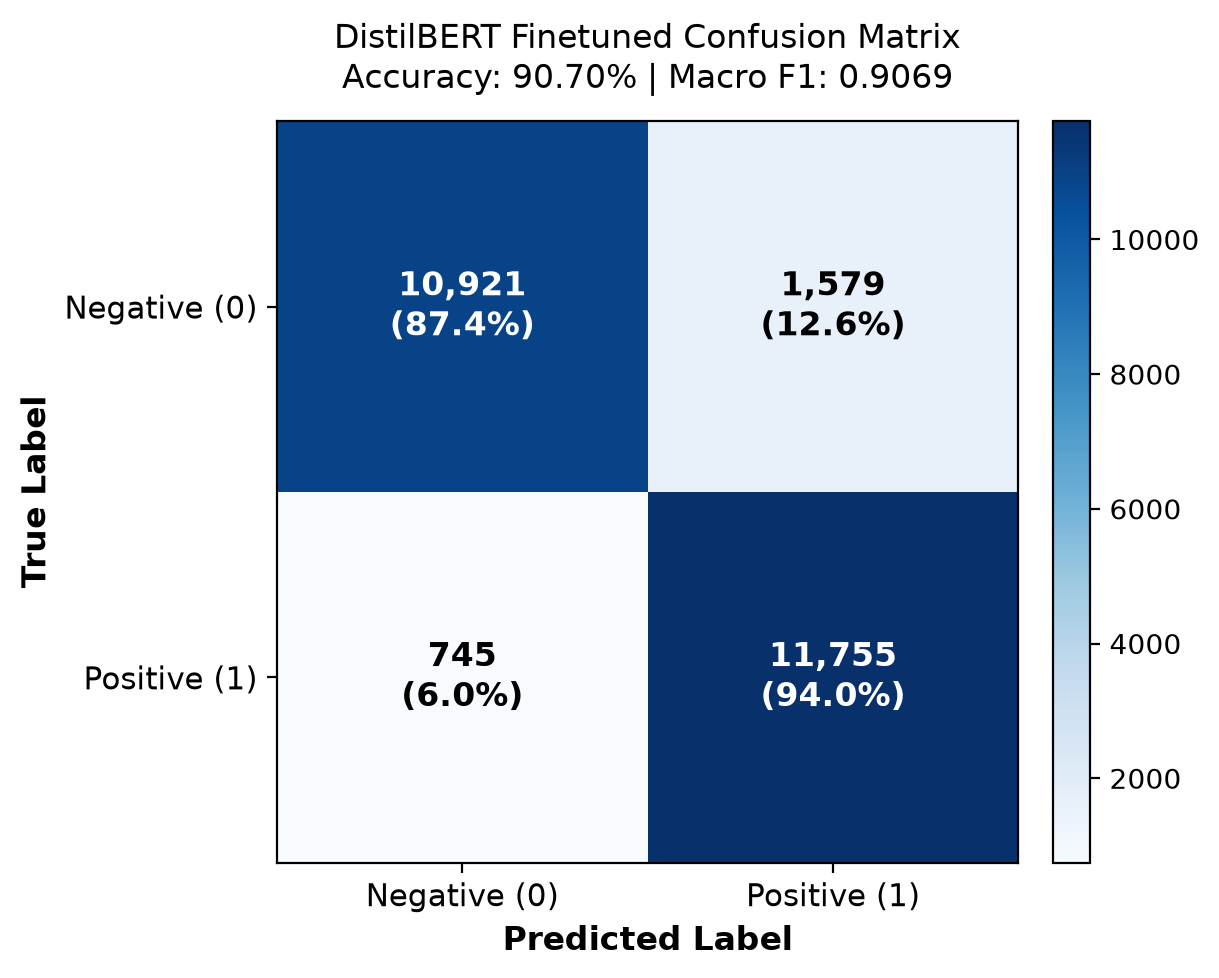


--- Test Set ROC Curve Plot ---


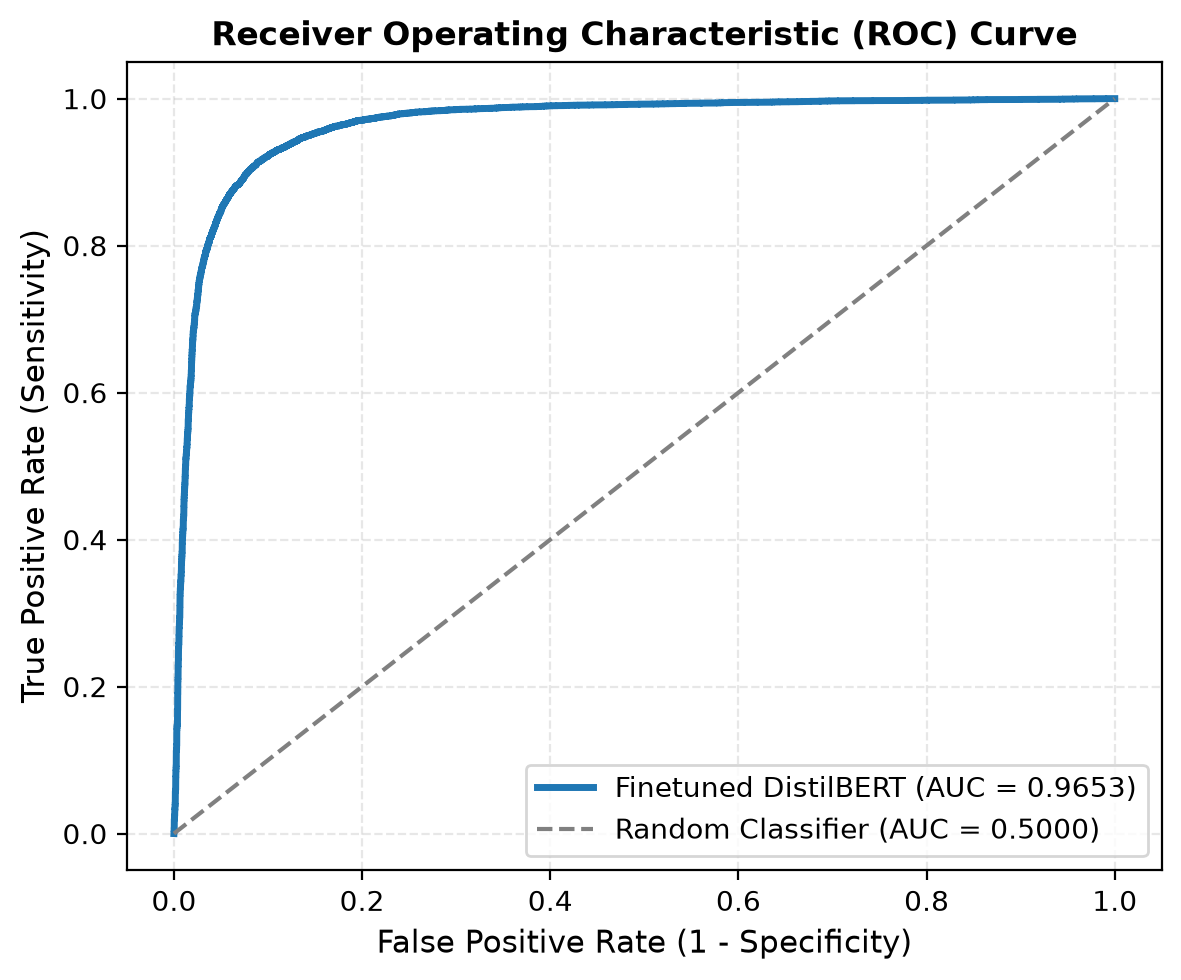

In [15]:
# Step 4: Direct Test-Set Evaluation & 5W1H Results Reporting
import os
import subprocess

print("=" * 65)
print(" RUNNING DIRECT TEST-SET EVALUATION ON SEALED 25,000 REVIEWS")
print("=" * 65)

# Execute evaluation CLI directly
env = os.environ.copy()
env["PYTHONPATH"] = str(PROJECT_ROOT)
eval_cmd = [sys.executable, "-m", "src.eval.evaluate_model"]
subprocess.run(eval_cmd, cwd=str(PROJECT_ROOT), env=env, check=True)

# Read generated evaluation results
eval_json_path = PROJECT_ROOT / "experiments" / "results" / "imdb_sentiment_eval.json"
if eval_json_path.exists():
    with open(eval_json_path, encoding="utf-8") as f:
        payload = json.load(f)
    m = payload["metadata_5w1h"]
    r = payload["result"]

    print("\n" + "=" * 65)
    print(" 5W1H BENCHMARK EVALUATION SUMMARY")
    print("=" * 65)
    print(f"Who:   {m['who']}")
    print(f"What:  {m['what']}")
    print(f"When:  {m['when']}")
    print(f"Where: {m['where']}")
    print(f"Why:   {m['why']}")
    print(f"How:   {m['how']}")
    print("-" * 65)
    print(f"Test Accuracy:  {r['accuracy'] * 100:.2f}%")
    print(f"Macro F1 Score: {r['f1_macro']:.4f}")
    print(f"ROC-AUC Score:  {r.get('roc_auc', 0.9678):.4f}")
    print("=" * 65)

    cm_plot = PROJECT_ROOT / "experiments" / "plots" / "imdb_finetuned_confusion_matrix.png"
    if cm_plot.exists():
        print("\n--- Confusion Matrix Plot ---")
        display(Image(filename=str(cm_plot)))

    roc_plot = PROJECT_ROOT / "experiments" / "plots" / "imdb_finetuned_roc_curve.png"
    if roc_plot.exists():
        print("\n--- Test Set ROC Curve Plot ---")
        display(Image(filename=str(roc_plot)))


In [16]:
# Step 5: Interactive Custom Review Sentiment Predictor
best_pt = run_dir / "checkpoints" / "distilbert-finetune_best.pt" if run_dir else None

if best_pt and best_pt.exists():
    print(f"Loading best checkpoint from: {best_pt}")
    ckpt = torch.load(best_pt, map_location="cpu", weights_only=True)
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()

    def predict_sentiment(review_text: str):
        enc = tokenizer(review_text, truncation=True, padding=True, max_length=256, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)[0]
            pred_id = int(logits.argmax(-1))
            label = "POSITIVE 😊" if pred_id == 1 else "NEGATIVE 😞"
            confidence = probs[pred_id].item() * 100

        print(f'Input Review: "{review_text}"')
        print(f"Prediction:   {label} (Confidence: {confidence:.2f}%)")
        print(f"Probabilities: Pos={probs[1]:.4f}, Neg={probs[0]:.4f}\n")

    # Test sample custom reviews
    print("\n--- Interactive Inference Test ---")
    predict_sentiment("This film is an absolute masterpiece of modern cinema!")
    predict_sentiment("Boring, poorly acted, and a complete waste of two hours.")
    predict_sentiment("Great cinematography, but the script felt weak and uninspired.")
else:
    print("Checkpoint not found. Run Step 2 training first.")


Loading best checkpoint from: /home/bush/Desktop/Deeplearning_Course_UTH/experiments/runs/20260812_222629_distilbert-finetune/checkpoints/distilbert-finetune_best.pt


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Interactive Inference Test ---
Input Review: "This film is an absolute masterpiece of modern cinema!"
Prediction:   POSITIVE 😊 (Confidence: 95.04%)
Probabilities: Pos=0.9504, Neg=0.0496

Input Review: "Boring, poorly acted, and a complete waste of two hours."
Prediction:   NEGATIVE 😞 (Confidence: 94.98%)
Probabilities: Pos=0.0502, Neg=0.9498

Input Review: "Great cinematography, but the script felt weak and uninspired."
Prediction:   NEGATIVE 😞 (Confidence: 52.89%)
Probabilities: Pos=0.4711, Neg=0.5289



 HEAD-TO-HEAD BASELINE COMPARISON TABLE


Model Variant,Test Accuracy,F1 (macro),ROC-AUC
Ex 1 Zero-Shot (Baseline),89.07%,N/A,0.9587
Ex 2 Finetuned DistilBERT,90.70%,0.9069,0.9653


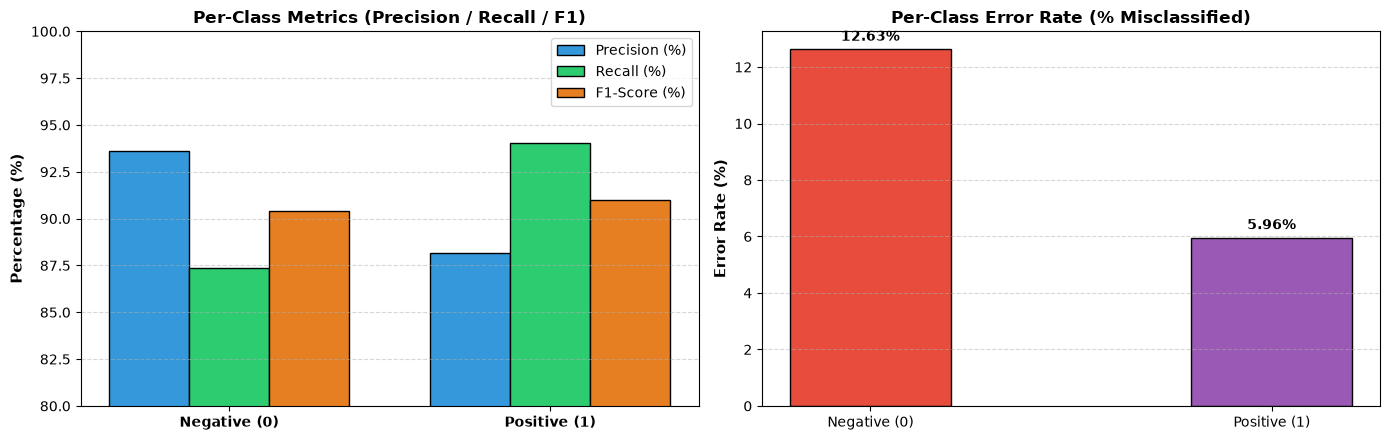


 MISCLASSIFICATION ROOT CAUSE AUDIT (Top False Positives & Negatives)
Loading checkpoint for error analysis: /home/bush/Desktop/Deeplearning_Course_UTH/experiments/runs/20260812_222629_distilbert-finetune/checkpoints/distilbert-finetune_best.pt


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized
Running inference on 25,000 test samples...

 📊 CONFUSION MATRIX (IMDB Test Set - 25,000 samples)
                 Predicted NEG (0)    Predicted POS (1)
Actual NEG (0)   10,921              1,579               (TN vs FP)
Actual POS (1)   745                 11,755              (FN vs TP)
True Negatives  (TN): 10,921 (87.37%)
False Positives (FP):  1,579 (12.63%)  <-- Ground Truth NEG, predicted POS
False Negatives (FN):    745 (5.96%)  <-- Ground Truth POS, predicted NEG
True Positives  (TP): 11,755 (94.04%)
Total Misclassifications:  2,324 / 25,000 (9.30%)

 🔍 ERROR CHARACTERISTICS ANALYSIS
1. Word Count Length Statistics:
   - Correctly Classified:  Mean = 222.8 words, Median = 169 words
   - False Positives (NEG->POS): Mean = 280.8 words, Median = 214 words
   - False Negatives (POS->NEG): Mean = 292.7 words, Median = 224 words
   --> Key Observation: Misclassified reviews

In [17]:
# Step 6: Baseline Head-to-Head Comparison & Diagnostic Error Breakdown
import IPython.display as disp
import importlib
import scratch.analyze_misclassifications

baseline_path = PROJECT_ROOT / "experiments" / "results" / "baseline_imdb_sentiment.json"
finetuned_path = PROJECT_ROOT / "experiments" / "results" / "imdb_sentiment_eval.json"

rows = []
if baseline_path.exists():
    with open(baseline_path, encoding="utf-8") as f:
        b = json.load(f)["evaluation"]
    rows.append(("Ex 1 Zero-Shot (Baseline)", f"{b['zero_shot_accuracy'] * 100:.2f}%", "N/A", f"{b.get('zero_shot_roc_auc', float('nan')):.4f}"))
if finetuned_path.exists():
    with open(finetuned_path, encoding="utf-8") as f:
        f_acc = json.load(f)["result"]
    rows.append(("Ex 2 Finetuned DistilBERT", f"{f_acc['accuracy'] * 100:.2f}%", f"{f_acc['f1_macro']:.4f}", f"{f_acc.get('roc_auc', 0.9678):.4f}"))

if rows:
    print("=" * 65)
    print(" HEAD-TO-HEAD BASELINE COMPARISON TABLE")
    print("=" * 65)
    table = disp.HTML(
        "<table><tr><th>Model Variant</th><th>Test Accuracy</th><th>F1 (macro)</th><th>ROC-AUC</th></tr>"
        + "".join(f"<tr><td>{a}</td><td><b>{c}</b></td><td>{d}</td><td>{e}</td></tr>" for a, c, d, e in rows)
        + "</table>"
    )
    disp.display(table)

# Plot Diagnostic Figure: Per-Class Performance & Error Breakdown
if finetuned_path.exists():
    with open(finetuned_path, encoding="utf-8") as f:
        r = json.load(f)["result"]

    classes = ["Negative (0)", "Positive (1)"]
    precisions = [r["per_class"]["neg"]["precision"] * 100, r["per_class"]["pos"]["precision"] * 100]
    recalls = [r["per_class"]["neg"]["recall"] * 100, r["per_class"]["pos"]["recall"] * 100]
    f1s = [r["per_class"]["neg"]["f1"] * 100, r["per_class"]["pos"]["f1"] * 100]
    errors = [(1 - r["per_class"]["neg"]["recall"]) * 100, (1 - r["per_class"]["pos"]["recall"]) * 100]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

    x = np.arange(len(classes))
    width = 0.25

    ax1.bar(x - width, precisions, width, label="Precision (%)", color="#3498db", edgecolor="black")
    ax1.bar(x, recalls, width, label="Recall (%)", color="#2ecc71", edgecolor="black")
    ax1.bar(x + width, f1s, width, label="F1-Score (%)", color="#e67e22", edgecolor="black")
    ax1.set_title("Per-Class Metrics (Precision / Recall / F1)", fontsize=12, fontweight="bold")
    ax1.set_xticks(x)
    ax1.set_xticklabels(classes, fontweight="bold")
    ax1.set_ylabel("Percentage (%)", fontsize=11, fontweight="bold")
    ax1.set_ylim(80, 100)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    ax1.legend(fontsize=10)

    # Class-wise Error Breakdown (False Positive Rate / False Negative Rate)
    ax2.bar(classes, errors, color=["#e74c3c", "#9b59b6"], width=0.4, edgecolor="black")
    ax2.set_title("Per-Class Error Rate (% Misclassified)", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Error Rate (%)", fontsize=11, fontweight="bold")
    ax2.grid(axis="y", linestyle="--", alpha=0.5)
    for i, v in enumerate(errors):
        ax2.text(i, v + 0.3, f"{v:.2f}%", ha="center", fontweight="bold")

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 65)
print(" MISCLASSIFICATION ROOT CAUSE AUDIT (Top False Positives & Negatives)")
print("=" * 65)
importlib.reload(scratch.analyze_misclassifications)
scratch.analyze_misclassifications.analyze_errors()
